In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
%% Sol·lució implementada Craig_7_1
%  Generació de trajectòries, Exemple 1.1
%  J.A.Mayugo, UdG, 2021
"""

import numpy as np
import matplotlib.pyplot as plt

# %% Funcio representació gràfica

def plot_xva(t_,x_,v_,a_):
# Representar posició, velocitat i acceleració
    plt.figure(figsize=(8, 3.3))
    plt.subplot(1, 3, 1)
    plt.plot(t_,x_)
    plt.ylabel(r'${\theta}$ [graus]')
    plt.xlabel(r'$t$ [s]')
    plt.gca().set_xlim([0, t_f])
    plt.subplot(1, 3, 2)
    plt.plot(t_,v_)
    plt.ylabel(r'$\dot{\theta}$ [graus/s]')
    plt.xlabel(r'$t$ [s]')
    plt.gca().set_xlim([0, t_f])
    plt.subplot(1, 3, 3)
    plt.plot(t_,a_)
    plt.ylabel(r'$\ddot{\theta}$ [graus/s$^2$]')
    plt.xlabel(r'$t$ [s]')
    plt.gca().set_xlim([0, t_f])
    plt.tight_layout()
    plt.show()

# %% DADES PROBLEMA
t_f = 3        # segons, temps
t_inc = 1/40   # segons, discretització a 40 Hz

theta_0 = 15   # degrees, angle inicial
theta_f = 75   # degrees, angle final

a_max = 40     # degrees/s2 acceleració màxima

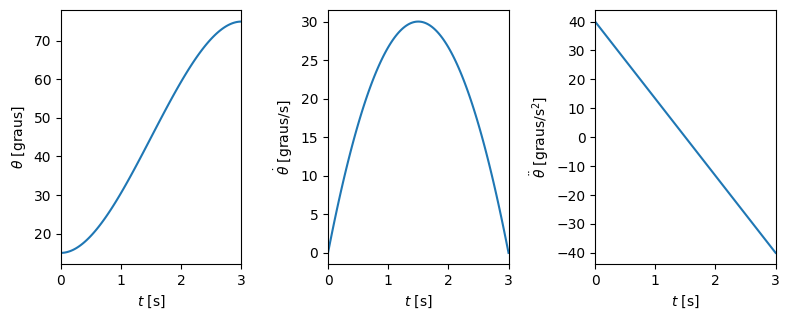

In [3]:
# %% Resolució: polinomi cúbic
theta = theta_f-theta_0

a0 = theta_0
a1 = 0
a2 = 3/t_f**2*(theta)
a3 = -2/t_f**3*(theta)

# Obtenir la trajectoria posicio, velocitat i acceleració
t_ = np.arange(0, t_f+t_inc, t_inc)
x_ = a0 + a2*t_**2 + a3*t_**3
v_ = 2*a2*t_ + 3*a3*t_**2
a_ = 2*a2 + 6*a3*t_

plot_xva(t_,x_,v_,a_) # Representar posició, velocitat i acceleració





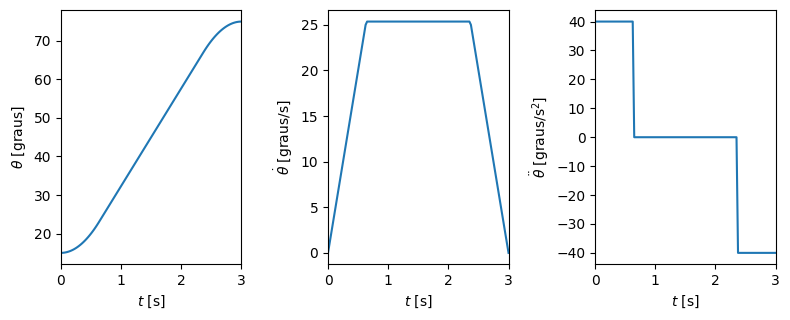

In [4]:
# %% Resolució: trapezoïdal
t_b    = t_f/2 - np.sqrt(a_max**2*t_f**2-4*a_max*(theta))/2/a_max
x_b    = 1/2*a_max*t_b**2

v_max   = t_b*a_max

# Definir trams de moviment: motion control
ti = np.array([t_b])
ti = np.append(ti, [ti[0] + t_f-2*t_b])
ti = np.append(ti, [ti[1] + t_b])

xi = np.array([theta_0 + 1/2*a_max*ti[0]**2])
xi = np.append(xi, [xi[0] + v_max*(ti[1]-ti[0])])
xi = np.append(xi, [xi[1] + v_max*(ti[2]-ti[1]) - 1/2*a_max*(ti[2]-ti[1])**2])

# Obtenir la trajectoria posicio, velocitat i acceleració
x_ = np.zeros(t_.shape)
v_ = np.zeros(t_.shape)
a_ = np.zeros(t_.shape)

for ii in np.arange(0,t_.shape[0]):
    if  t_[ii] <= ti[0]:
        x_[ii] = theta_0 + 1/2*a_max*t_[ii]**2
        v_[ii] = a_max*t_[ii]
        a_[ii] = a_max
    elif  t_[ii]  <= ti[1]:
        x_[ii] = xi[0] + v_max*(t_[ii]-ti[0])
        v_[ii] = v_max
        a_[ii] = 0
    else: #  t_[ii]  <= ti[2]:
        x_[ii] = xi[1] + v_max*(t_[ii]-ti[1]) - 1/2*a_max*(t_[ii]-ti[1])**2
        v_[ii] = v_max - a_max*(t_[ii]-ti[1])
        a_[ii] = -a_max

plot_xva(t_,x_,v_,a_) # Representar posició, velocitat i acceleració

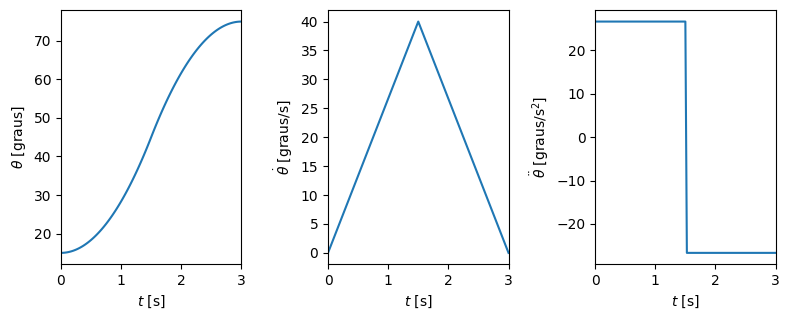

In [5]:
# %% Resolució: triangular
a_max = 4*theta/t_f**2

t_b    = t_f/2
x_b    = 1/2*a_max*t_b**2

v_max   = t_b*a_max

# Definir trams de moviment: motion control
ti = np.array([t_b])
ti = np.append(ti, [ti[0] + t_b])

xi = np.array([theta_0 + 1/2*a_max*ti[0]**2])
xi = np.append(xi, [xi[0] + v_max*(ti[1]-ti[0]) - 1/2*a_max*(ti[1]-ti[0])**2])


# Obtenir la trajectoria posicio, velocitat i acceleració
x_ = np.zeros(t_.shape)
v_ = np.zeros(t_.shape)
a_ = np.zeros(t_.shape)

for ii in np.arange(0,t_.shape[0]):
    if  t_[ii] <= ti[0]:
        x_[ii] = theta_0 + 1/2*a_max*t_[ii]**2
        v_[ii] = a_max*t_[ii]
        a_[ii] = a_max
    else: #  t_[ii]  <= ti[1]:
        x_[ii] = xi[0] + v_max*(t_[ii]-ti[0]) - 1/2*a_max*(t_[ii]-ti[0])**2
        v_[ii] = v_max - a_max*(t_[ii]-ti[0])
        a_[ii] = -a_max

plot_xva(t_,x_,v_,a_) # Representar posició, velocitat i acceleració